<a href="https://colab.research.google.com/github/kibwale/nipe_macho/blob/main/notebooks/testing_new_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Augmentation Using the RDD2020 Road Damage Dataset

## Motivation

Following the analysis of the **Chepalungu pothole dataset**, we observed that although the dataset captured road conditions within the study area, its relatively limited size and geographic scope could restrict the model's ability to generalize to unseen environments.

To improve the diversity of the training data, we investigated the use of an external road damage dataset that could supplement our locally collected images. Rather than replacing the Chepalungu dataset, our objective was to augment it with additional annotated images representing a wider range of road damage types, lighting conditions, weather conditions, road surfaces, and camera viewpoints.

For this purpose, we selected the **RDD2020 (Road Damage Detection 2020)** dataset, a publicly available benchmark developed through an international collaboration for automated road damage detection. The dataset contains thousands of annotated road images collected from multiple countries, making it well suited for improving the robustness and generalization capability of deep learning models.

**RDD2020 Dataset:** https://github.com/sekilab/RoadDamageDetector

In the following sections, we download the dataset, convert its annotations into the YOLO format, verify the generated labels, and prepare the data for integration with the existing Chepalungu dataset prior to model training.

In [ ]:
!nvidia-smi

Mon Jul 20 15:07:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Environment Setup & Custom Modules

To streamline the analysis, we use our custom framework, **Fynesse** (its  like a utility folder), which provides reusable utilities for dataset preparation and model development.

We begin by cloning the project repository from GitHub. The following cell removes any existing local copy, downloads the latest version of the repository, and adds it to the Python path, making the custom modules available for use throughout the notebook.

In [1]:
# Remove existing repository folder to ensure a clean clone and setup
!pip install -q ultralytics
import shutil
shutil.rmtree("/content/nipe_macho", ignore_errors=True)
# Clone the latest version of the repository from GitHub

!git clone https://github.com/silprosa/nipe_macho.git
import os, subprocess, importlib, sys
sys.path.append("/content/nipe_macho")
from fynesse import access , assess , address
import pandas as pd
from matplotlib import pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.8 MB/s eta 0:00:00
Cloning into 'nipe_macho'...
remote: Enumerating objects: 379, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 379 (delta 97), reused 73 (delta 73), pack-reused 260 (from 1)
Receiving objects: 100% (379/379), 36.42 MiB | 22.36 MiB/s, done.
Resolving deltas: 100% (200/200), done.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
from google.colab import userdata
# !pip install -q ultralytics # Moved to oLbK9d7BHg7p
from ultralytics import YOLO
import os
import xml.etree.ElementTree as ET
from pathlib import Path
!pip install roboflow
from roboflow import Roboflow
!pip install -q kaggle
import random
import hashlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8


## 2. Loading Datasets

For convenience, we obtain a Kaggle-hosted copy of the **RDD2020** dataset. The following cell authenticates with the Kaggle API using stored credentials and downloads the dataset directly into the Colab environment, where it is automatically extracted for subsequent preprocessing.

In [3]:
os.environ['KAGGLE_KEY'] =userdata.get("kaggleme")
!kaggle datasets download -d ziedkelboussi/rdd2020-dataset -p /content/rdd2020 --unzip

Dataset URL: https://www.kaggle.com/datasets/ziedkelboussi/rdd2020-dataset
License(s): unknown
100% 1.38G/1.38G [00:17<00:00, 86.6MB/s]



As described previously, the Chepalungu dataset is retrieved directly from Roboflow using the project API and downloaded in .txt format for subsequent integration with the RDD2020 dataset

In [ ]:
api_key = userdata.get('roboflow_api')
rf = Roboflow(api_key=api_key)
project = rf.workspace("nipemacho").project("chepalungu")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chepalungu-1 in yolov8:: 100%|██████████| 527/527 [00:00<00:00, 3694.51it/s]


## 3. Converting the RDD2020 Annotations

The RDD2020 dataset uses XML annotations, which are incompatible with YOLO.

In [ ]:
xml_file = next(Path("/content/rdd2020").rglob("*.xml"))
print(xml_file)
tree = ET.parse(xml_file)
root = tree.getroot()
ET.dump(root)

/content/rdd2020/train/Czech/annotations/xmls/Czech_001546.xml
<annotation>
  <folder>images</folder>
  <filename>Czech_001546.jpg</filename>
  <size>
    <depth>3</depth>
    <width>600</width>
    <height>600</height>
  </size>
  <object>
    <name>D00</name>
    <bndbox>
      <xmin>175</xmin>
      <ymin>407</ymin>
      <xmax>237</xmax>
      <ymax>465</ymax>
    </bndbox>
  </object>
  <object>
    <name>D00</name>
    <bndbox>
      <xmin>304</xmin>
      <ymin>405</ymin>
      <xmax>361</xmax>
      <ymax>513</ymax>
    </bndbox>
  </object>
  <object>
    <name>D00</name>
    <bndbox>
      <xmin>105</xmin>
      <ymin>448</ymin>
      <xmax>167</xmax>
      <ymax>506</ymax>
    </bndbox>
  </object>
  <object>
    <name>D10</name>
    <bndbox>
      <xmin>166</xmin>
      <ymin>409</ymin>
      <xmax>303</xmax>
      <ymax>427</ymax>
    </bndbox>
  </object>
  <object>
    <name>D10</name>
    <bndbox>
      <xmin>231</xmin>
      <ymin>473</ymin>
      <xmax>403</xmax>
    

In [ ]:
classes = set()

for xml_file in Path("/content/rdd2020").rglob("*.xml"):
    root = ET.parse(xml_file).getroot()
    for obj in root.findall("object"):
        classes.add(obj.find("name").text)

print(f"Found {len(classes)} classes:")
print(sorted(classes))

Found 10 classes:
['D00', 'D01', 'D0w0', 'D10', 'D11', 'D20', 'D40', 'D43', 'D44', 'D50']



> **Why retain only the D40 class?**  
> The objective of this study is to improve pothole detection, not general road damage detection. Since the Chepalungu dataset contains only potholes, retaining all RDD2020 damage categories (e.g., longitudinal cracks, transverse cracks, alligator cracks) would introduce additional classes that are not present in the original dataset therefore we only retain the  **D40** class


The following cell converts the annotations to the YOLO format, retains only the **D40 (pothole)** class, and generates the corresponding dataset configuration file (`data.yaml`) for training.

In [ ]:
DRIVE_ROOT = "/content/rdd2020"
TARGET_CLASSES = ["D40"]  # pothole only, becomes class 0

classes = access.convert_dataset(DRIVE_ROOT, TARGET_CLASSES)
access.write_data_yaml(DRIVE_ROOT, classes)

Found 3 annotation folders
Converted 2829 files in /content/rdd2020/train/Czech
Converted 7706 files in /content/rdd2020/train/India
Converted 10506 files in /content/rdd2020/train/Japan

Total boxes: 5627
Images containing at least one target box: 3074
data.yaml written to /content/rdd2020/data.yaml


### 3.1 Dataset Quality Assessment

After retaining only the **D40 (pothole)** class, many images no longer contain annotations because they originally contained other types of road damage. before proceeding with dataset augmentation and model training, we perform a sanity check to quantify the distribution of annotated and empty images across the training subsets



In [ ]:
for country in ["Japan", "Czech", "India"]:
    lbl_dir = Path(f"/content/rdd2020/train/{country}/labels")
    files = list(lbl_dir.glob("*.txt"))
    empty = sum(1 for f in files if f.stat().st_size == 0)
    nonempty = len(files) - empty
    print(f"{country}: {nonempty} with pothole, {empty} empty ({empty/len(files)*100:.1f}% empty)")

Japan: 1390 with pothole, 9116 empty (86.8% empty)
Czech: 154 with pothole, 2675 empty (94.6% empty)
India: 1530 with pothole, 6176 empty (80.1% empty)


This assessment provides an estimate of the available pothole samples and helps identify the proportion of images that would contribute little or no learning signal if included during training. Understanding this distribution informs subsequent preprocessing decisions, such as whether to retain or remove empty-label images prior to model training.

In [ ]:
for country in ["Japan", "Czech", "India"]:
    assess.subsample_negatives( DRIVE_ROOT,country,keep_ratio=1.5)

Japan: 1390 positive, 2085 negatives kept, 7031 negatives removed
Czech: 154 positive, 231 negatives kept, 2444 negatives removed
India: 1530 positive, 2295 negatives kept, 3881 negatives removed


### 3.3 Consolidating the Dataset and Creating the Training Split

Following preprocessing, the country-specific subsets are consolidated into a single unified dataset. Images and their corresponding annotations are randomly partitioned into **training (85%)** and **validation (15%)** sets while preserving image-label pairs. To prevent filename collisions between countries, each file is prefixed with its country of origin before being copied into the unified directory structure.

Finally, a new `data.yaml` configuration file is generated to reference the consolidated dataset, preparing it for subsequent model training with YOLO.

In [ ]:
DRIVE_ROOT = "/content/rdd2020"
ROBOFLOW_ROOT = dataset.location
FINAL_ROOT = "/content/rdd2020/final"
VAL_RATIO = 0.2
random.seed(42)

# unified output dirs
final_train_img = Path(f"{DRIVE_ROOT}/final/train/images")
final_train_lbl = Path(f"{DRIVE_ROOT}/final/train/labels")
final_val_img = Path(f"{DRIVE_ROOT}/final/val/images")
final_val_lbl = Path(f"{DRIVE_ROOT}/final/val/labels")

for d in [final_train_img, final_train_lbl, final_val_img, final_val_lbl]:
    d.mkdir(parents=True, exist_ok=True)

# Kenya (Roboflow) — already pre-split, copy each split as-is
assess.copy_split(ROBOFLOW_ROOT, "train", f"{DRIVE_ROOT}/final", "train", prefix="Kenya")
assess.copy_split(ROBOFLOW_ROOT, "valid", f"{DRIVE_ROOT}/final", "val", prefix="Kenya")
assess.copy_split(ROBOFLOW_ROOT, "test", f"{DRIVE_ROOT}/final", "test", prefix="Kenya")

# RDD2020 countries — need splitting, val_ratio triggers the split path
for country in ["Japan", "Czech", "India"]:
    assess.copy_split(src_root=DRIVE_ROOT,src_split=f"train/{country}", dst_root=f"{DRIVE_ROOT}/final",
        dst_split="train",   # ignored when val_ratio is set, but harmless to pass
        prefix=country,
        val_ratio=0.2,
    )

access.write_data_yaml( f"{DRIVE_ROOT}/final", ["D40"], train_subdir="train/images", val_subdir="val/images")


Kenya -> train: 183 images
Kenya -> val: 52 images
Kenya -> test: 26 images
Japan: 2780 train, 695 val
Czech: 308 train, 77 val
India: 3060 train, 765 val
data.yaml written to /content/rdd2020/final/data.yaml


In [ ]:
results = {}
for split in ["train", "val"]:
    results[split] = access.fix_polygon_labels(FINAL_ROOT, split, prefix="Kenya_")

train: fixed 132 files, converted 344 polygon lines to boxes
val: fixed 38 files, converted 99 polygon lines to boxes


In [ ]:
sizes, countries_list = assess.collect_box_sizes(DRIVE_ROOT)
widths, heights, areas = assess.print_size_summary(sizes)
assess.print_size_buckets(areas)


Total pothole boxes (final dataset): 6070
Width  (% of image): mean=13.6%, min=0.6%, max=99.7%
Height (% of image): mean=7.8%, min=0.1%, max=59.3%
Area   (% of image): mean=1.6%, min=0.0%, max=51.1%

Small boxes (<1% area):  4017 (66.2%)
Medium boxes (1-9%):     1834 (30.2%)
Large boxes (>9%):       219 (3.6%)


{'small': 4017, 'medium': 1834, 'large': 219}

In [ ]:
by_country = assess.group_by_country(countries_list, areas)
assess.print_country_breakdown(by_country)



--- Per-country box counts and mean area ---
India: 3187 boxes, mean area=2.29%, small=54.2%
Japan: 2243 boxes, mean area=0.93%, small=77.4%
Czech: 197 boxes, mean area=0.58%, small=85.8%
Kenya: 443 boxes, mean area=0.99%, small=87.1%


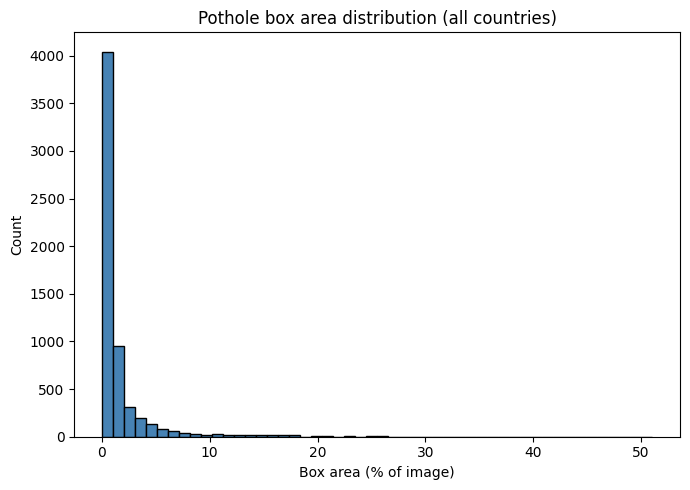

In [ ]:
assess.plot_area_histogram(areas)

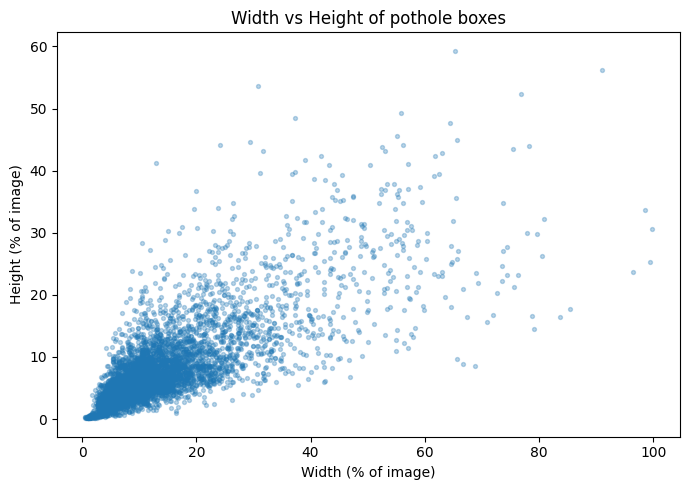

In [ ]:
assess.plot_width_vs_height(widths, heights)

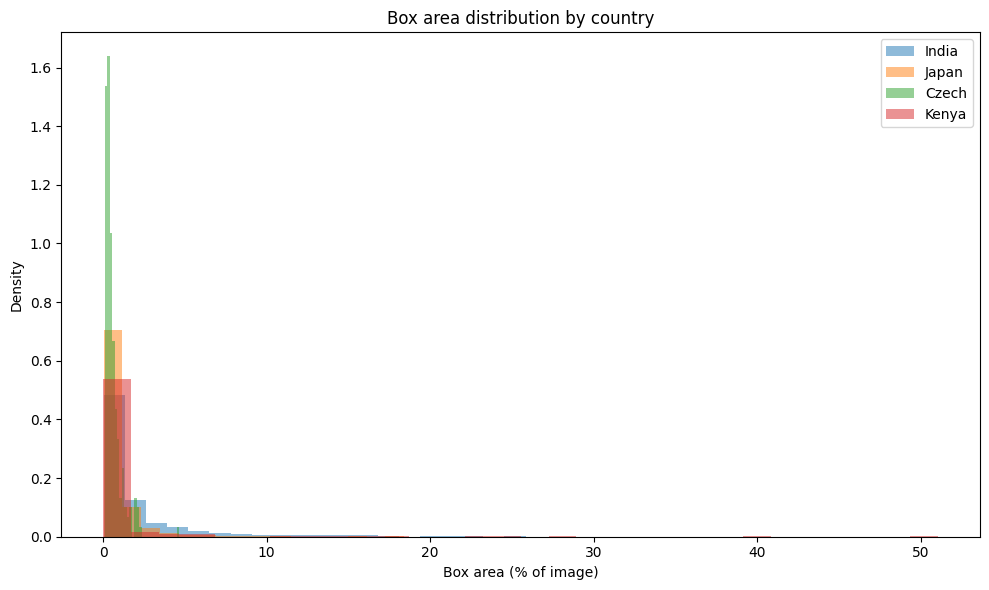

In [ ]:
assess.plot_area_by_country(by_country)
#assess.check_country(FINAL_ROOT, country="kenya")

In [ ]:
for split in ["train", "val"]:
    img_dir = Path(f"/content/rdd2020/final/{split}/images")
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")

    img_stems = {f.stem for f in img_dir.glob("*")}
    lbl_stems = {f.stem for f in lbl_dir.glob("*.txt")}

    missing_labels = img_stems - lbl_stems
    orphaned_labels = lbl_stems - img_stems

    print(f"{split}: {len(img_stems)} images, {len(lbl_stems)} labels")
    print(f"  Missing labels: {len(missing_labels)}")
    print(f"  Orphaned labels: {len(orphaned_labels)}")

train: 6331 images, 6331 labels
  Missing labels: 0
  Orphaned labels: 0
val: 1589 images, 1589 labels
  Missing labels: 0
  Orphaned labels: 0


In [ ]:
bad_lines = assess.is_box_or_polygon(FINAL_ROOT)

Found 0 genuinely problematic label lines


In [ ]:
overlap = assess.check_train_val_overlap(FINAL_ROOT)#checks duplicates in train and validation

Duplicate images between train and val: 0


In [4]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
os.makedirs("/content/drive/MyDrive/potholes/runs", exist_ok=True)

Mounted at /content/drive


NameError: name 'os' is not defined

# 4. Model Development

The prepared dataset is used to train and evaluate multiple YOLO models for pothole detection.
The experiments investigate the effect of
* **input image resolution** on detection performance,
* compare the accuracy of different **YOLO architectures** (YOLOv8, YOLO11, and YOLO26)
* assess their **inference times** to evaluate their suitability for real-time deployment.

### Training Configuration


In [ ]:
DATA = "/content/rdd2020/final/data.yaml"
PROJECT = "/content/drive/MyDrive/potholes/runs"
IMAGESIZE =960
NAME="baseline_8S-960"
model = YOLO("yolov8s.pt")
#all remaining hyperparameters use the default values provided by  Ultralytics


 The input image resolution and YOLO architecture are varied according to the experiment. Unless otherwise stated, all experiments use the same training configuration to ensure a fair comparison between models.



In [ ]:

model.train(data=DATA,imgsz= IMAGESIZE ,epochs=100,patience=25,seed=42,name=NAME, project=PROJECT)

Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2020/final/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_8S-960, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

###  Training Results

Upon completion of training, Ultralytics automatically generates a `results.csv` file containing the training and validation losses, together with the evaluation metrics recorded at each epoch. The following cells load this file and visualize the model's learning progress.**bold text**

In [ ]:
import pandas as pd
results_path = "/content/drive/MyDrive/potholes/runs/8S-800/baseline_8S-800/results.csv"
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.tail(2)

#### Loss Curves

The training and validation loss curves are plotted to assess the convergence of the model and identify potential underfitting or overfitting during training.





In [5]:
loss_pairs = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Class Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]

assess.plot_row(df, loss_pairs)

NameError: name 'assess' is not defined

- **`box_loss`** — is the box in the right place/size?
- **`cls_loss`** — does it correctly tell pothole vs background?
- **`dfl_loss`** — how precise are the box edges? (matters most for small objects)

#### Performance Metrics

The evolution of precision, recall, and mAP@50 is visualized across the training epochs to evaluate the detector's performance and convergence.

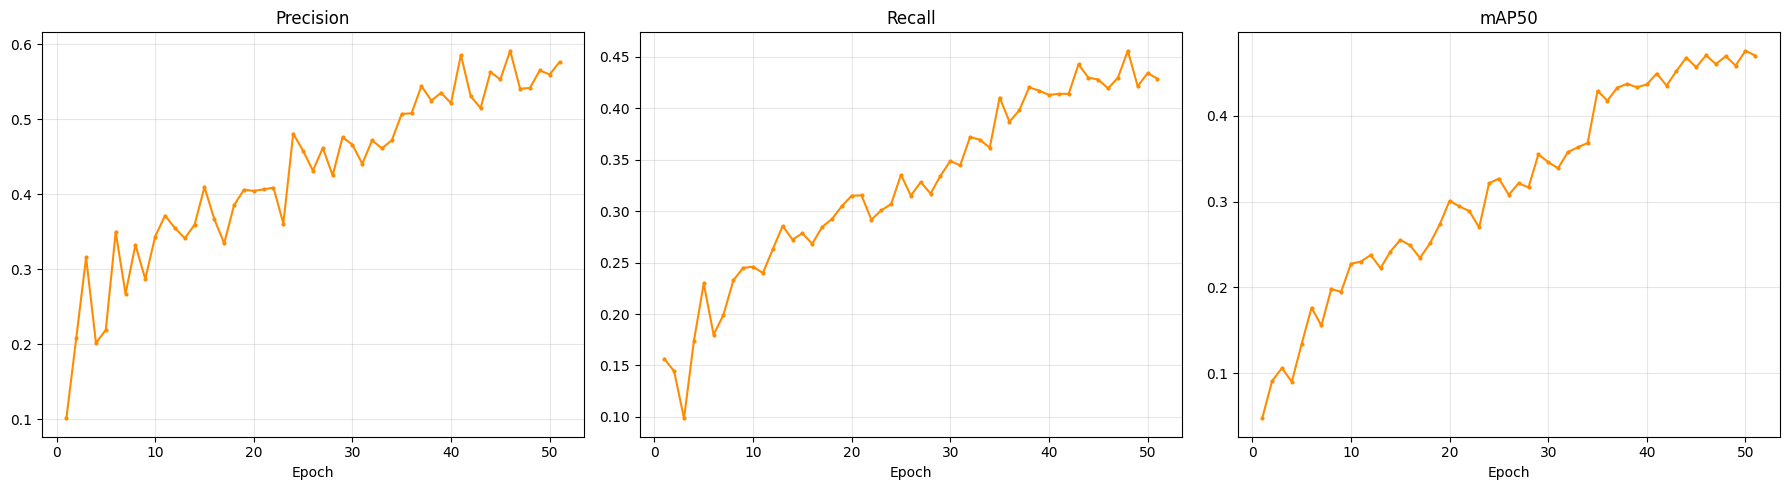

In [10]:
metrics = [
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)", "Recall"),
    ("metrics/mAP50(B)", "mAP50"),
]

assess.plot_row(df, metrics)

---
## Evaluation

###  Image Resolution Comparison

To evaluate the effect of input image resolution on detection performance, the results from the **640×640**, **800×800**, and **960×960** training runs are compared.

In [4]:
def load_results(run_path):
    df = pd.read_csv(f"{run_path}/results.csv")
    df.columns = df.columns.str.strip()
    return df

 For each experiment, the epoch achieving the highest **mAP@50** is identified, and the corresponding precision, recall, mAP@50, and mAP@50–95 metrics are summarized for comparison.

In [ ]:
import pandas as pd

def summarize_runs(runs, label_name):
    """
    Summarize the best-performing epoch for multiple YOLO training runs.

    Parameters
    ----------
    runs : dict
        Dictionary mapping a label (e.g., image size or model name)
        to the corresponding training run directory.
    label_name : str
        Name of the identifier column in the output
        (e.g., 'imgsz' or 'model').

    Returns
    -------
    pandas.DataFrame
        Summary of the best epoch from each run.
    """
    summary = []

    for label, path in runs.items():
        df = pd.read_csv(f"{path}/results.csv")
        df.columns = df.columns.str.strip()

        best = df.loc[df["metrics/mAP50(B)"].idxmax()]

        summary.append({
            label_name: label,
            "best_epoch": int(best["epoch"]),
            "precision": best["metrics/precision(B)"],
            "recall": best["metrics/recall(B)"],
            "mAP50": best["metrics/mAP50(B)"],
            "mAP50-95": best["metrics/mAP50-95(B)"],
        })

    return pd.DataFrame(summary)

In [3]:
runs_pixel = {
    "640": "/content/drive/MyDrive/potholes/runs/train_backup",
    "800": "/content/drive/MyDrive/potholes/runs/8S-800/baseline_8S-800",
    "960": "/content/drive/MyDrive/potholes/runs/s_960-2",
}
#or each experiment, the epoch achieving the highest mAP@50 is identified,
#and the corresponding performance metrics are summoned for comparison.
pixel_df = assess.summarize_runs(
    runs_pixel,
    label_name="imgsz"
)

pixel_df

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/potholes/runs/train_backup/results.csv'

In [ ]:
import matplotlib.pyplot as plt
def plot_bar(df, x_col, metric="mAP50", title=None, pad=0.01):
    plt.figure(figsize=(7,5))
    plt.bar(df[x_col].astype(str), df[metric])

    ymin = max(0, df[metric].min() - pad)
    ymax = min(1, df[metric].max() + pad)
    plt.ylim(ymin, ymax)

    plt.xlabel(x_col)
    plt.ylabel(metric)
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)

    # value labels
    for i, v in enumerate(df[metric]):
        plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")

    plt.show()
def plot_metric_bar(df, x_col, metric="mAP50", title=None):
    """
    Plot a bar chart comparing a metric across experiments.

    Parameters
    ----------
    df : pandas.DataFrame
        Summary dataframe.
    x_col : str
        Column used for the x-axis (e.g. 'imgsz' or 'model').
    metric : str
        Metric to plot.
    title : str, optional
        Plot title.
    """
    plt.figure(figsize=(7, 5))
    plt.bar(df[x_col].astype(str), df[metric])
    plt.xlabel(x_col.replace("_", " ").title())
    plt.ylabel(metric)
    plt.title(title or f"{metric} comparison")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [2]:
assess.plot_bar(
    pixel_df,
    x_col="imgsz",
    title="YOLOv8s — mAP50 by Image Resolution"
)

NameError: name 'pixel_df' is not defined

<Figure size 700x500 with 0 Axes>

> **Result:** Increasing the input image resolution is generally expected to improve detection performance by providing finer spatial detail, particularly for small or distant potholes. However, these gains often diminish at higher resolutions while increasing training time, memory usage, and computational cost. The optimal resolution therefore represents a balance between detection accuracy and efficiency.

###  YOLO Architecture Comparison

Using the selected input image resolution, the performance of **YOLOv8s**, **YOLO11s**, and **YOLO26s** is compared under identical training conditions.

In [ ]:
runs_model = {
    "YOLOv8s": "/content/drive/MyDrive/potholes/runs/800s/baseline_s_800",   # or winning imgsz path
    "YOLOv11s": "/content/drive/MyDrive/potholes/runs/v11/v11s_800",
    "YOLOv26s": "/content/drive/MyDrive/potholes/runs/v26/v26s_800",
}

model_df = assess.summarize_runs(runs_model,label_name="model")
model_df

In [ ]:
assess.plot_bar(model_df,x_col="model",title="mAP50 by YOLO Architecture")

> **Outcome:** Different YOLO architectures are expected to exhibit varying detection performance despite being trained under identical conditions. While newer architectures may achieve higher precision and mAP through improved feature extraction and optimization strategies, these gains should be evaluated alongside their computational requirements to determine the most suitable model for pothole detection.



---


## 5. Inference on Unseen Data

The ultimate test of an object detection model is its performance on data it has never seen before. In this final section, we load our newly trained custom weights (`best.pt`) and run inference on the Test dataset.

 We set a confidence threshold of `0.25`, meaning the model will only draw a bounding box if it is at least 25% confident that the detected object is a pothole. Finally, we randomly sample and display the resulting images to visually verify the model's predictive accuracy.

## 5. Qualitative Inference Results

To qualitatively assess the detector's performance, the trained model is applied to randomly selected images from the held-out test set. A confidence threshold of **0.25** is used to filter low-confidence detections, and the resulting predictions are visualized by overlaying the detected potholes with their corresponding bounding boxes. This provides a visual assessment of the model's ability to generalize to previously unseen road images.

In [5]:
test_dir = Path("/content/rdd2020/final/test/images")
image_path = random.choice(list(test_dir.glob("*")))

# Load the selected trained model (YOLO26s)
results_dir = "/content/drive/MyDrive/potholes/runs/v26/v26s_800"
model = address.load_trained_model(results_dir)
results = model.predict( source=str(image_path), conf=0.25,save=True)

#address.display_prediction(address.find_latest_predict_dir())

NameError: name 'Path' is not defined

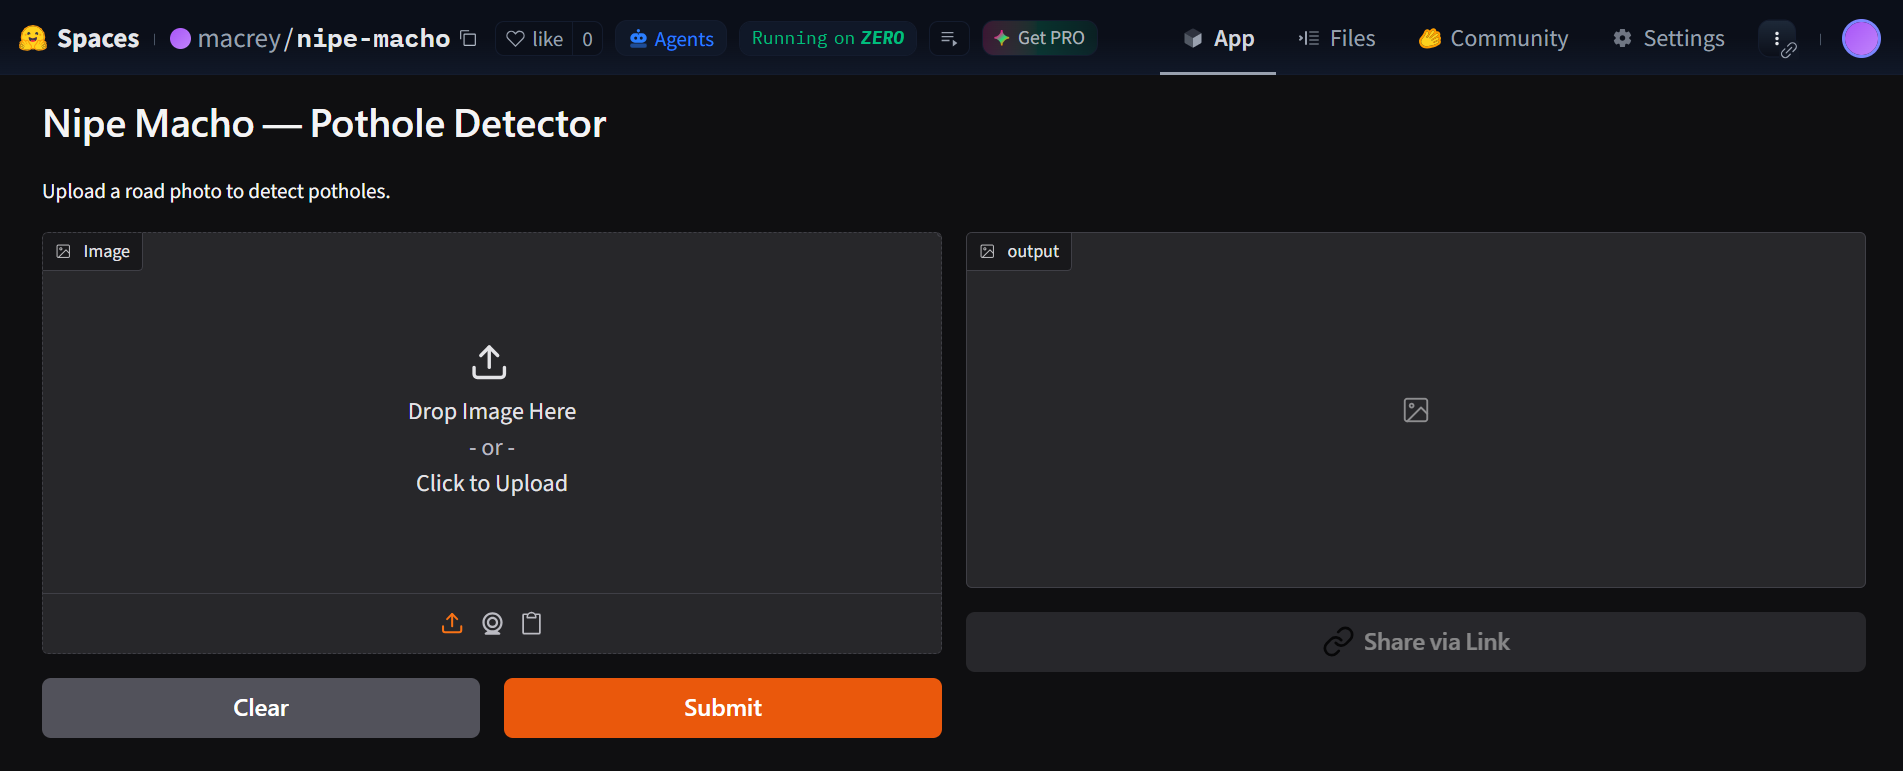

In [ ]:

FINAL_ROOT = "/content/rdd2020/final"  # or wherever your test split lives

test_images = list(Path(f"{FINAL_ROOT}/test/images").glob("*.jpg"))
random_image = random.choice(test_images)
print(f"Selected: {random_image}")

model = address.load_trained_model(results_dir)
address.run_inference(model, str(random_image), conf=0.25)

latest = address.find_latest_predict_dir()
address.display_random_predictions(latest, n=1)

In [ ]:
import time
import address

FINAL_ROOT = "/content/rdd2020/final"

test_images = list(Path(f"{FINAL_ROOT}/test/images").glob("*.jpg"))
random_image = random.choice(test_images)
print(f"Selected: {random_image}")

# Load the selected trained model (YOLO26s)
results_dir = "/content/drive/MyDrive/potholes/runs/v26/v26s_800"
model = address.load_trained_model(results_dir)

# warm-up call — first prediction includes model/CUDA setup overhead,
# so time it separately and don't count it in your measurement
model.predict(str(random_image), conf=0.25, verbose=False)

# now time the actual inference
start = time.time()
address.run_inference(model, str(random_image), conf=0.25)
elapsed = time.time() - start

print(f"Inference time: {elapsed*1000:.2f} ms")

In [ ]:
import time

def measure_inference_time(weights_path, test_images_path, n_images=50, imgsz=800):
    model = YOLO(weights_path)
    from pathlib import Path
    img_files = list(Path(test_images_path).glob("*.jpg"))[:n_images]

    # warm-up run (first call includes model/graph setup overhead)
    model.predict(img_files[0], imgsz=imgsz, verbose=False)

    start = time.time()
    for img in img_files:
        model.predict(img, imgsz=imgsz, verbose=False)
    elapsed = time.time() - start

    avg_ms = (elapsed / len(img_files)) * 1000
    return avg_ms

test_images_path = f"{dataset.location}/test/images"

inference_summary = []
weights_paths = {
    "YOLOv8s": "/content/drive/MyDrive/potholes/runs/800s/baseline_s_800/weights/best.pt",
    "YOLOv11s": "/content/drive/MyDrive/potholes/runs/v11/v11s_800/weights/best.pt",
    "YOLOv26s": "/content/drive/MyDrive/potholes/runs/v26/v26s_800/weights/best.pt",
}

for name, wpath in weights_paths.items():
    avg_ms = measure_inference_time(wpath, test_images_path, n_images=50, imgsz=800)
    inference_summary.append({"model": name, "avg_inference_ms": avg_ms})
    print(f"{name}: {avg_ms:.2f} ms/image")

inference_df = pd.DataFrame(inference_summary)
inference_df

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(inference_df["model"], inference_df["avg_inference_ms"], color="seagreen")
plt.xlabel("Model")
plt.ylabel("Avg inference time (ms/image)")
plt.title("Inference speed by model version")
plt.show()

Loaded model from: /content/drive/MyDrive/potholes/runs/train_backup/weights/best.pt
Running predictions on: /content/chepalungu-1/test/images

image 1/26 /content/chepalungu-1/test/images/IMG_20241223_124318_jpg.rf.2a7165695765e7435a7d2a251f6ca041.jpg: 640x640 (no detections), 650.0ms
image 2/26 /content/chepalungu-1/test/images/IMG_20241223_124512_jpg.rf.3f09f5cf532a0931c69233607209b71a.jpg: 640x640 4 D40s, 1310.7ms
image 3/26 /content/chepalungu-1/test/images/IMG_20241223_124730_jpg.rf.b6f73c67e54a4d33d39df0e232a5f95f.jpg: 640x640 1 D40, 667.8ms
image 4/26 /content/chepalungu-1/test/images/IMG_20241223_124732_jpg.rf.bfa5133b5972689508e32546759cbb22.jpg: 640x640 (no detections), 598.9ms
image 5/26 /content/chepalungu-1/test/images/IMG_20241223_124734_jpg.rf.f45e3c80d9a8513fd6edb1d4bf7d1b9b.jpg: 640x640 2 D40s, 583.2ms
image 6/26 /content/chepalungu-1/test/images/IMG_20241223_124927_jpg.rf.7533d31f3e831d06fd9b2dbae8b18e91.jpg: 640x640 1 D40, 600.8ms
image 7/26 /content/chepalungu-1/te

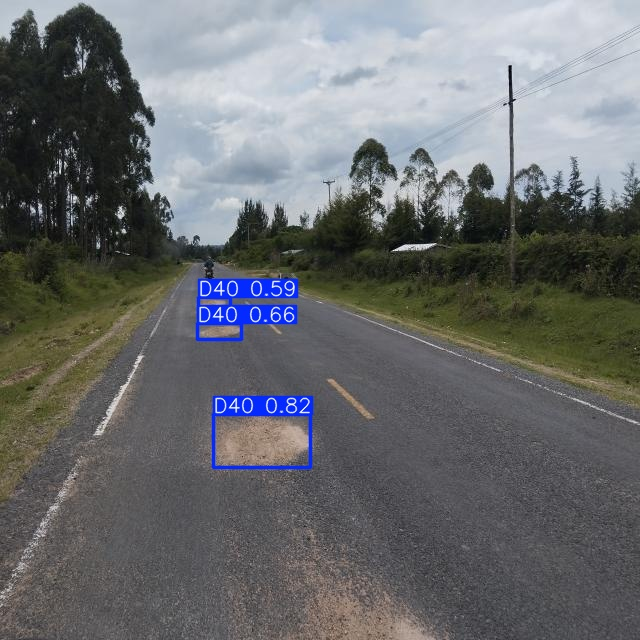

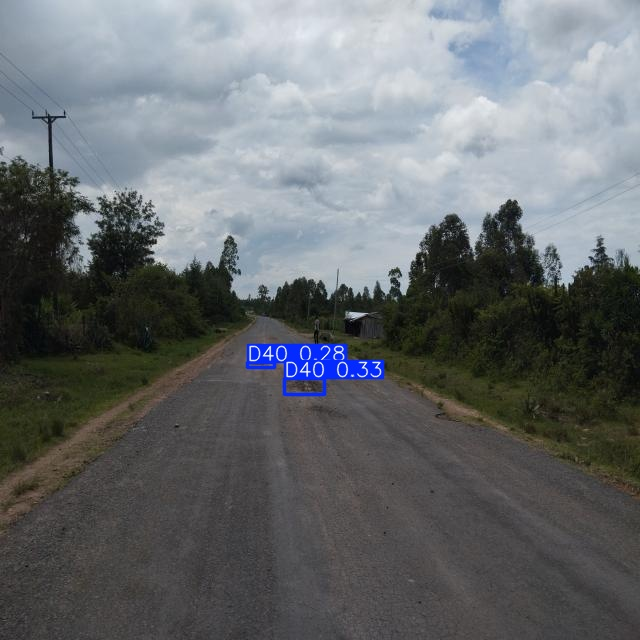

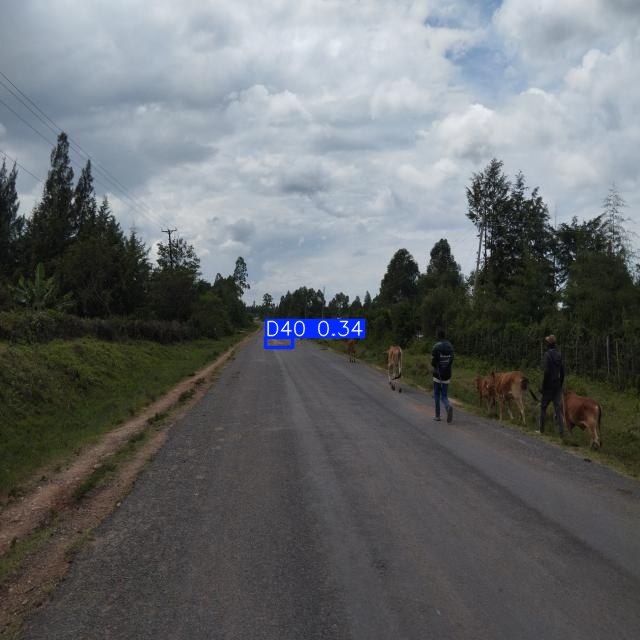

In [ ]:
import random
from pathlib import Path
import address

FINAL_ROOT = "/content/rdd2020/final"  # or wherever your test split lives

test_images = list(Path(f"{FINAL_ROOT}/test/images").glob("*.jpg"))
random_image = random.choice(test_images)
print(f"Selected: {random_image}")

model = address.load_trained_model(results_dir)
address.run_inference(model, str(random_image), conf=0.25)

latest = address.find_latest_predict_dir()
address.display_random_predictions(latest, n=1)

In [ ]:
import time

def measure_inference_time(weights_path, test_images_path, n_images=50, imgsz=800):
    model = YOLO(weights_path)
    from pathlib import Path
    img_files = list(Path(test_images_path).glob("*.jpg"))[:n_images]

    # warm-up run (first call includes model/graph setup overhead)
    model.predict(img_files[0], imgsz=imgsz, verbose=False)

    start = time.time()
    for img in img_files:
        model.predict(img, imgsz=imgsz, verbose=False)
    elapsed = time.time() - start

    avg_ms = (elapsed / len(img_files)) * 1000
    return avg_ms

test_images_path = f"{dataset.location}/test/images"

inference_summary = []
weights_paths = {
    "YOLOv8s": "/content/drive/MyDrive/potholes/runs/800s/baseline_s_800/weights/best.pt",
    "YOLOv11s": "/content/drive/MyDrive/potholes/runs/v11/v11s_800/weights/best.pt",
    "YOLOv26s": "/content/drive/MyDrive/potholes/runs/v26/v26s_800/weights/best.pt",
}

for name, wpath in weights_paths.items():
    avg_ms = measure_inference_time(wpath, test_images_path, n_images=50, imgsz=800)
    inference_summary.append({"model": name, "avg_inference_ms": avg_ms})
    print(f"{name}: {avg_ms:.2f} ms/image")

inference_df = pd.DataFrame(inference_summary)
inference_df

In [ ]:
plt.figure(figsize=(7,5))
plt.bar(inference_df["model"], inference_df["avg_inference_ms"], color="seagreen")
plt.xlabel("Model")
plt.ylabel("Avg inference time (ms/image)")
plt.title("Inference speed by model version")
plt.show()